Библиотеки которые можно использовать: librosa, NMFToolbox, Nimfa, Mido/Pretty_midi,MIDIUtil.

Из всех библиотек с реализацией NMF пока остановился на Nimfa, не пойдет с ней - буду пробовать работать с NMFToolbox. Перед тем как запускать код дальше надо установить Nimfa.

In [2]:
pip install nimfa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 51.5 MB/s eta 0:00:00


In [3]:
!grep -rl "np.mat" /usr/local/lib/python3.12/dist-packages/nimfa | xargs sed -i 's/np.mat/np.asmatrix/g'
!grep -rl "asmatrixrix" /usr/local/lib/python3.12/dist-packages/nimfa | xargs sed -i 's/asmatrixrix/asmatrix/g'
!grep -R "asmatrixrix" /usr/local/lib/python3.12/dist-packages/nimfa

Попробуем CQT вместо STFT, мб результаты будут лучше

In [ ]:
import numpy as np
K = 3
def frec(p,K):
  return 440 * 2**((p*K-49*K)/(12*K))
def harmonic_template(p, coef=3, t=0.1):
  vec = np.zeros((88 * coef))
  fq = frec(p,1)
  fu = 440 * 2 ** (39/12)
  tpls = []
  m = int(np.floor(fu / fq))
  for fr in range(m):
    i_s = int(np.ceil(np.log2(((fq * (fr+1) * (1-t/2)) / 440)) * (12 * coef) + 49 * coef))
    i_f = int(np.floor(np.log2(((fq * (fr+1) * (1+t/2)) / 440)) * (12 * coef) + 49 * coef))
    for k in range(i_s-1,i_f):
      vec[k] = 1
  return vec

harmonic_template(49)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
       1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
       0., 0., 0., 0., 0.

In [ ]:
print(frec(69,1))

1396.9129257320155


/usr/local/lib/python3.12/dist-packages/nimfa/models/nmf.py:589: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if self.seed is not None and self.seed is not "fixed":
/usr/local/lib/python3.12/dist-packages/nimfa/methods/seeding/random.py:60: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if sn[0] is 'S' and sn[1:].isdigit():
/usr/local/lib/python3.12/dist-packages/nimfa/methods/factorization/sepnmf.py:276: SyntaxWarning: invalid escape sequence '\m'
  .. math:: \arg\min_{Y \ge 0} \| V - W H \|_F.


nof_bins= 324
114
1.0009928792024216


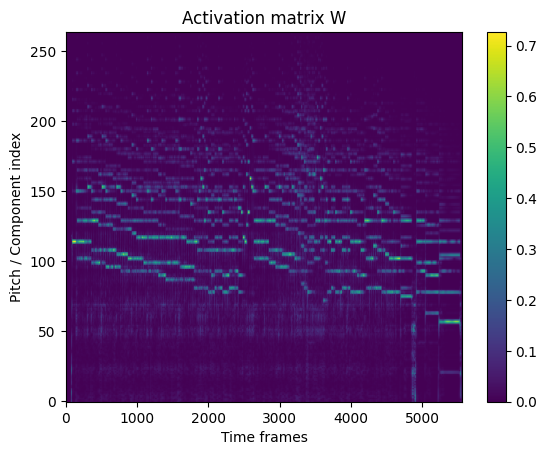

In [4]:
from scipy.io import wavfile
import numpy as np
import librosa
import nimfa
g = 2
HOP = 1024
K = 3
f_s, x = wavfile.read("/content/Prelude-in-E-Minor-Nr-4.wav")

def norm_log(H, gamma=5):
    return np.log1p(gamma * H)
def frec(p,K):
  return 440 * 2**((p*K-49*K)/(12*K))
def harmonic_template(p, coef=3, t=0.1):
  vec = np.zeros((88 * coef))
  fq = frec(p,1)
  fu = 440 * 2 ** (39/12)
  tpls = []
  m = int(np.floor(fu / fq))
  for fr in range(m):
    i_s = max(0,int(np.ceil(np.log2(((fq * (fr+1) * (1-t/2)) / 440)) * (12 * coef) + 49 * coef))-1)
    i_f = min(int(np.floor(np.log2(((fq * (fr+1) * (1+t/2)) / 440)) * (12 * coef) + 49 * coef)), 88 * coef)
    if(i_s==i_f):
      vec[i_s] = 1
    for k in range(i_s,i_f):
      vec[k] = 1
  return vec
def init_W(coef=3, t=0.1):
  vec = np.zeros((88 * coef, 88))
  for i in range(88):
    vec[:,i] = harmonic_template(i,coef,t)
  return vec

def sparsity(x, eps=1e-10):
    x = np.asarray(x).ravel()
    N = x.size

    if N <= 1:
        return 0.0  # not defined, fallback

    l2_norm = np.sqrt(np.sum(x**2)) + eps

    term = np.sum(np.tanh(np.abs(x)**2)) / l2_norm

    return (np.sqrt(N) - term) / (np.sqrt(N) - 1)

if(x.dtype==np.int32):
  x = x / (2**31)
elif(x.dtype==np.int16):
  x = x / (2**15)
else:
  raise ValueError(f"Unsupported sample type: {x.dtype}")
onsets = librosa.onset.onset_detect(y=x, sr=f_s, hop_length=HOP,units='frames')
nof_bins = int(np.floor(np.log2(f_s / (2 * librosa.note_to_hz('A0')))) * (12 * K))
print("nof_bins=",nof_bins)
spectrogram = np.abs(librosa.cqt(x,sr=f_s, fmin=librosa.note_to_hz('A0'), bins_per_octave=12 * K, n_bins=88 * K, hop_length=HOP))
#spectrogram = np.abs(librosa.cqt(x,sr=f_s, fmin=librosa.note_to_hz('A0'), bins_per_octave=12 * K, n_bins=nof_bins, hop_length=HOP))
spectrogram_norm = norm_log(spectrogram, g)
spectrogram_norm = librosa.util.normalize(spectrogram_norm, norm = 2, axis = 0, threshold = 0.05)

max_index = np.argmax(spectrogram_norm[:,onsets[0]+5])
print(max_index)  # 1
print(sparsity(spectrogram_norm[:,onsets[10]+5]))
#spectrogram_compressed = np.log(1+gamma*spectrogram)

W_i = init_W(3,0.08)
import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(H_v, aspect='auto', origin='lower')
#plt.imshow(Y[:,140:160], aspect='auto', origin='lower')
plt.imshow(spectrogram_norm, aspect='auto', origin='lower')
#plt.imshow(W_i, aspect='auto', origin='lower')
#plt.imshow(Y, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix W")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()



[[1. 1. 0. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [1. 1. 1. ... 0. 0. 1.]
 [1. 1. 1. ... 0. 0. 1.]
 [1. 1. 1. ... 0. 0. 0.]]
(264, 88)


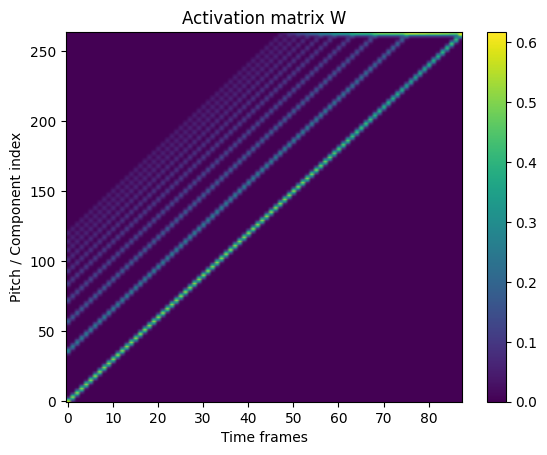

In [9]:
def build_W0(sr,
             bins_per_octave,
             n_bins,
             fmin,
             n_harmonics=10,
             decay=1.0,
             sigma=1.5,
             inharmonicity=0.0):

    # CQT frequency grid (MUST match your spectrogram)
    freqs = librosa.cqt_frequencies(
        n_bins=n_bins,
        fmin=fmin,
        bins_per_octave=bins_per_octave
    )

    midi_notes = np.arange(21, 21 + 88)  # piano
    W0 = np.zeros((n_bins, len(midi_notes)))

    for i, m in enumerate(midi_notes):
        f0 = librosa.midi_to_hz(m)
        template = np.zeros(n_bins)

        for h in range(1, n_harmonics + 1):
            # optional piano inharmonicity
            fh = h * f0 * np.sqrt(1 + inharmonicity * h**2)

            if fh >= sr / 2:
                break

            # nearest bin
            idx = np.argmin(np.abs(freqs - fh))

            # Gaussian spread
            k = np.arange(n_bins)
            peak = np.exp(-(k - idx)**2 / (2 * sigma**2))

            template += (1 / (h ** decay)) * peak

        # normalize (critical)
        template /= np.linalg.norm(template) + 1e-10

        W0[:, i] = template

    return W0

W_0 = build_W0(sr=f_s, bins_per_octave=12*K, n_bins=88 * K, fmin=librosa.note_to_hz('A0'))
print(W_i)

print(W_i.shape)
import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(H_v, aspect='auto', origin='lower')
#plt.imshow(Y[:,140:160], aspect='auto', origin='lower')
plt.imshow(W_0, aspect='auto', origin='lower')
#plt.imshow(W_i, aspect='auto', origin='lower')
#plt.imshow(Y, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix W")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()

In [6]:
H_0 = np.random.rand(88, spectrogram_norm.shape[1])
#nmf = nimfa.Nmf(spectrogram_compressed, seed='fixed', W=W_temp)
nmf = nimfa.Nmf(
    spectrogram_norm,
    rank=K,
    seed='fixed',
    W=W_0,
    H=H_0,
    max_iter=200,
    beta=1, sparsity=(None, 0.2),
    objective='div',
    update='divergence'
)
nmf_fit = nmf()
W_est = nmf_fit.basis()
H_est = nmf_fit.coef()

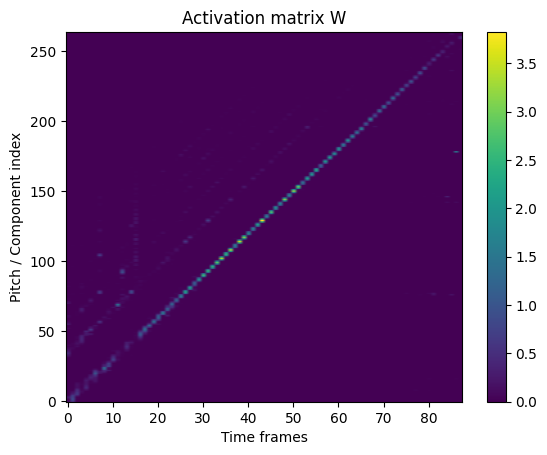

In [29]:
import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(H_v, aspect='auto', origin='lower')
#plt.imshow(Y[:,140:160], aspect='auto', origin='lower')
plt.imshow(W_est, aspect='auto', origin='lower')
#plt.imshow(W_i, aspect='auto', origin='lower')
#plt.imshow(Y, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix W")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()

In [ ]:
print(onsets)
print(len(onsets))

[  87  140  152  181  233  255  278  300  325  353  384  407  430  453
  479  500  526  553  583  606  629  656  684  706  765  794  817  840
  895  920  983 1013 1037 1061 1087 1112 1135 1161 1191 1221 1244 1268
 1292 1318 1339 1364 1394 1420 1445 1467 1489 1512 1533 1567 1579 1591
 1616 1638 1688 1743 1767 1815 1838 1860 1884 1911 1934 1956 1986 2014
 2036 2058 2083 2134 2157 2188 2239 2283 2340 2358 2370 2411 2451 2478
 2501 2523 2544 2573 2596 2611 2631 2664 2687 2710 2733 2758 2784 2812
 2841 2869 2889 2911 2933 2956 2958 2979 2982 3001 3024 3026 3050 3072
 3095 3117 3162 3181 3201 3203 3229 3239 3250 3269 3272 3277 3283 3288
 3296 3314 3333 3355 3370 3382 3404 3428 3452 3472 3494 3516 3537 3560
 3580 3602 3623 3631 3641 3663 3689 3714 3744 3769 3800 3823 3845 3867
 3942 3953 3980 4007 4030 4077 4103 4130 4160 4181 4199 4231 4254 4279
 4305 4334 4360 4385 4418 4448 4472 4498 4525 4584 4620 4690 4909 5036
 5228]
183


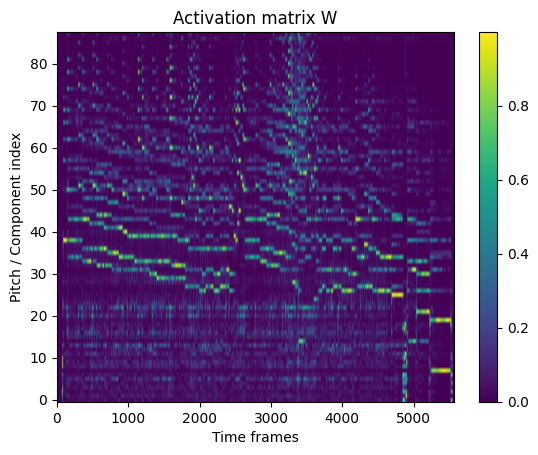

In [28]:
from scipy.ndimage import label
def enforce_min_duration(B, min_len=10):
    for q in range(B.shape[0]):
        labels, n = label(B[q])
        for i in range(1, n+1):
            if np.sum(labels == i) < min_len:
                B[q][labels == i] = 0
    return B
def matrix_filter(H):
  H_c = H.copy()
  for i in range(H_c.shape[0]):
    for j in range(H_c.shape[1]):
      v = 0
      if ((j-1)>=0):
        v += H_c[i,j-1]
      if((j+1)<H_c.shape[1]):
        v += H_c[i,j+1]
      v += H_c[i,j]
      v = v / 3
      H_c[i,j] = v
  return H_c
def rowwise_norm(H, eps=1e-8):
    Hn = H.copy()
    for q in range(H.shape[0]):
        m = np.max(Hn[q])
        if m > eps:
            Hn[q] /= m
    return Hn
#Y = norm_dynamic_range(H_new)
Y = rowwise_norm(H_est)
Y = matrix_filter(Y)
#Y = unsharp_matrix(Y)
#Y = np.maximum(0, Y)
#Y = freq_ftr(Y)
#Y = binarize_matrix(Y)
#Y = track_notes(Y)
Y = enforce_min_duration(Y)
import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(H_v, aspect='auto', origin='lower')
#plt.imshow(Y[:,140:160], aspect='auto', origin='lower')
plt.imshow(Y, aspect='auto', origin='lower')
#plt.imshow(W_i, aspect='auto', origin='lower')
#plt.imshow(Y, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix W")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()

/tmp/ipykernel_15535/679558634.py:76: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if(float(sc*fr[peaks[p]])<=thr):
/tmp/ipykernel_15535/679558634.py:78: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  notes.append((peaks[p],float(sc*fr[peaks[p]])))


[42, 36, 5]


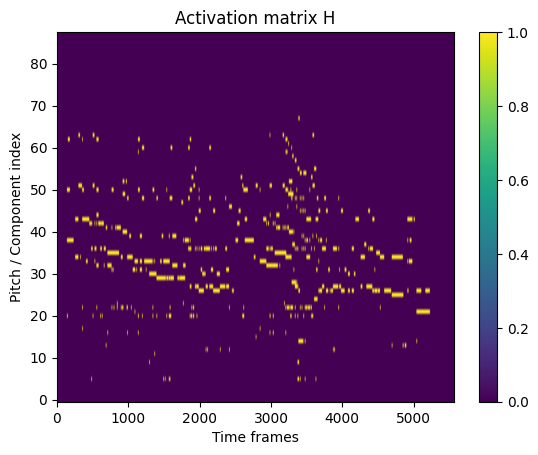

In [42]:

def pitch_energy(fp,p):
  en = 0
  en_t = np.sum(np.square(fp))
  h = pitch_harmonics(p)
  h = [m for m in h if m <= 87]
  alpha = -1
  #print(h)
  for l in range(len(h)):
    en += (l+2)**alpha * fp[h[l]]**2
    #print(l,h[l])
  #print(en)
  return float(en)
'''def transcribe_frame(fr,pol=9):
  peaks = [int(p) for p in top_k_indices(fr,20)]
  notes = []
  thr = np.median(fr,axis=0)
  thr += 0.1
  alpha = -1
  print(fr.shape)
  for p in peaks:
    #a = [p+12,p+19,p+24,p+28,p+31,p+34,p+36]
    if(fr[p]>thr):
      a = pitch_harmonics(p)
      sc = 0
      for pt in range(len(a)):
        if a[pt] in peaks:
          sc += (pt+2)**alpha
      #notes.append((p,float(fr[p,0]),len(set(a) & set(peaks))))
      #notes.append((p,float(fr[p,0]),sc))
      notes.append((p,pitch_energy(fr,p)))
  notes = sorted(notes, key=lambda x: x[1],reverse=True)
  return notes
  print(notes)'''
'''def top_k_indices(v, k):
    v = np.asarray(v).ravel()      # ensure 1D ndarray
    return np.argpartition(v, -k)[-k:]'''

def top_k_indices(v, k):
    v = np.asarray(v).ravel()          # ensure 1D
    idx = np.argpartition(v, -k)[-k:]  # indices of k largest elements
    idx = idx[np.argsort(v[idx])[::-1]]  # sort them by value (descending)
    return idx
def pitch_harmonics(p):
  r = [p+12,p+19,p+24,p+28,p+31,p+34,p+36]
  return [m for m in r if m <= 87]
def transcribe_frame(fr,thr=0.15):
  frn = fr.copy()
  peaks = [int(p) for p in top_k_indices(fr,20)]
  #peaks = [int(p) for p in range(88) if fr[p] > 0.25]
  peaks = sorted(peaks)
  #print(peaks)
  alpha = 0.5
  rv_start = 0.7
  #rv_start = 1
  notes = []
  for p in range(len(peaks)):
    frns = frn.copy()
    sc = 0
    en = fr[peaks[p]]
    pch = pitch_harmonics(peaks[p])
    ind = []
    for idx in range(len(pch)):
      if(frn[pch[idx]]>rv_start*(alpha)**idx):
        sc += 1/(idx+1)
        '''* float(frn[pch[idx]])**2'''
        frn[pch[idx]] -= rv_start*(alpha)**idx
        ind.append(idx)
    #score correction
    '''if(peaks[p]<=87):
      sc *= 2**((peaks[p] - 69) / 12)'''
    #sc *= float(frn[peaks[p]]/(np.max(frn)))
    #notes.append((peaks[p],sc))
    '''if(float(sc*fr[peaks[p]])<=thr):
      for i in ind:
        frn[pch[i]] += rv_start*(alpha)**i'''
    if(float(sc*fr[peaks[p]])<=thr):
      frn = frns
    notes.append((peaks[p],float(sc*fr[peaks[p]])))
  notes = sorted(notes, key=lambda x: x[1],reverse=True)
  notes = list(filter(lambda t: t[1] > thr, notes))
  return [t[0] for t in notes]
  #print(notes)

def transcribe_onset(m):
  st = np.zeros((88,))
  #ln = m.shape[1] // 2
  r = []
  #print("ln",ln)
  for j in range(m.shape[1]):
    for l in transcribe_frame(m[:,j]):
      st[l] +=1
  ap = [int(p) for p in top_k_indices(st,88)]
  s = 0
  summa = np.sum(st)
  for el in ap:
    s += st[el]
    if(s>=round((0.7 * summa)) or st[el]==0):
      break
    r.append(el)
    #print(el,st[el])
    #if(st[el]>ln):
    #  r.append(el)
  #print(np.sum(st))

  #print(st[ap[0]],st[ap[1]])
  #return ap
  #print(st[ap[0]],st[ap[1]])
  #print(st)
  return r
def transcribe_H(Y,os):
  tr = np.zeros(Y.shape)
  for idx in range(len(os)-1):
    nts = transcribe_onset(Y[:,os[idx]:os[idx]+10])
    for n in nts:
      tr[n,os[idx]:os[idx]+10] = 1
    for i in range(os[idx]+10,os[idx+1]):
      for n in nts:
        if(np.max(Y[n,i-4:i+4])>0.5):
          tr[n,i] = 1
        #else:
        #  nts.remove(n)
      #if(len(nts)==0):
        #break
  '''nts = transcribe_onset(Y[:,os[len(os)-1]:os[len(os)-1]+10])
  for n in nts:
    tr[n,os[len(os)-1]:os[len(os)-1]+10] = 1
  print(Y.shape[1])
  for i in range(os[len(os)-1]+10,Y.shape[1]-5):
    for n in nts:
      if(np.max(Y[n,i-4:i+5])>0.5):
        tr[n,i] = 1'''
  return tr

def pitch_energy(fp,p):
  en = 0
  en_t = np.sum(np.square(fp))
  h = pitch_harmonics(p)
  h = [m for m in h if m <= 87]
  #print(h)
  for l in h:
    en += fp[l]**2
  #print(en)
  return float(en/en_t)
  #return en[0,0]
#print(transcribe_frame(H_m[:,1]))
print(transcribe_onset(Y[:,479:489]))
#print(transcribe_frame(Y[:,152]))
#print(Y[38,203],Y[39,203])

trscrptn = transcribe_H(Y,onsets)
trscrptn[0,:] = 0
trscrptn = enforce_min_duration(trscrptn,min_len=10)
import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(H_v, aspect='auto', origin='lower')
#plt.imshow(Y[:,140:160], aspect='auto', origin='lower')
#plt.imshow(Y[:,479:489], aspect='auto', origin='lower')
plt.imshow(trscrptn, aspect='auto', origin='lower')
#plt.imshow(Y, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix H")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()

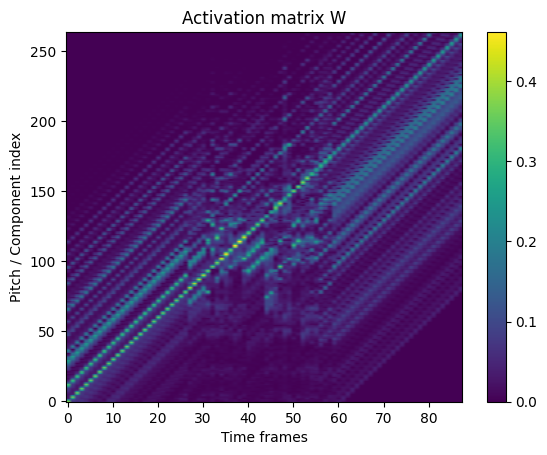

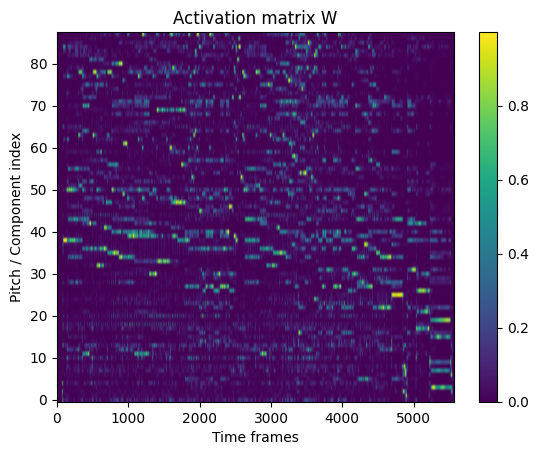

In [ ]:
from scipy.ndimage import label
def shift(x, k, fill=0):
    y = np.full_like(x, fill)
    if k > 0:
        y[k:] = x[:-k]
    elif k < 0:
        y[:k] = x[-k:]
    else:
        y = x.copy()
    return y
def compute_W(spectrogram_norm,onsets):
  W = np.zeros((88*K,88))
  pitch_list = []
  for i in range(len(onsets)):
    m_index = np.argmax(spectrogram_norm[:,onsets[i]])
    s_index = np.argsort(spectrogram_norm[:,onsets[i]])[-2]
    if((m_index // K) not in pitch_list and m_index % K == 0 and spectrogram_norm[s_index,onsets[i]] < 0.9 * spectrogram_norm[m_index,onsets[i]]):
      W[:,m_index // K] = spectrogram_norm[:,onsets[i]]
      pitch_list.append(int(m_index // K))
  pitch_list.sort()
  for i in range(88):
    if(i not in pitch_list):
      if(i < max(pitch_list)):
        for en in pitch_list:
          if(en > i):
            W[:,i] = shift(W[:,en],(i-en)*K)
            break
      else:
        W[:,i] = shift(W[:,max(pitch_list)],(i-en)*K)
  W_norm = W / np.linalg.norm(W, axis=0, keepdims=True)
  #W_norm = W / (np.max(W, axis=0, keepdims=True) + 1e-12)
  #print(pitch_list)
  return W_norm
  #max_index = np.argmax(spectrogram_norm[:,onsets])
  #tmpl = harmonic_template(39,3,0.08)
  #r = spectrogram_norm[:,onsets[0]] * tmpl
  #max_index = np.argmax(r)'''
import numpy as np
#print(max_index)
def rowwise_norm(H, eps=1e-8):
    Hn = H.copy()
    for q in range(H.shape[0]):
        m = np.max(Hn[q])
        if m > eps:
            Hn[q] /= m
    return Hn
def matrix_filter(H):
  H_c = H.copy()
  for i in range(H_c.shape[0]):
    for j in range(H_c.shape[1]):
      v = 0
      if ((j-1)>=0):
        v += H_c[i,j-1]
      if((j+1)<H_c.shape[1]):
        v += H_c[i,j+1]
      v += H_c[i,j]
      v = v / 3
      H_c[i,j] = v
  return H_c
def enforce_min_duration(B, min_len=10):
    for q in range(B.shape[0]):
        labels, n = label(B[q])
        for i in range(1, n+1):
            if np.sum(labels == i) < min_len:
                B[q][labels == i] = 0
    return B
def polyphony_autocorr(V, max_lag=200, threshold=0.3):
    F, T = V.shape
    P = np.zeros(T)

    for t in range(T):
        v = V[:, t]
        v = v / (np.max(v) + 1e-10)

        # autocorrelation (positive lags only)
        R = np.correlate(v, v, mode='full')[F-1:F-1+max_lag]

        # normalize
        R /= np.max(R) + 1e-10

        # peak counting
        peaks = (R[1:-1] > R[:-2]) & (R[1:-1] > R[2:])
        peaks = peaks & (R[1:-1] > threshold)

        P[t] = np.sum(peaks)

    return P


W_i = compute_W(spectrogram_norm, onsets)
import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(H_v, aspect='auto', origin='lower')
#plt.imshow(Y[:,140:160], aspect='auto', origin='lower')
#plt.imshow(spectrogram_norm, aspect='auto', origin='lower')
plt.imshow(W_i, aspect='auto', origin='lower')
#plt.imshow(Y, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix W")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()



H_i = np.random.rand(88, spectrogram_norm.shape[1])
#nmf = nimfa.Nmf(spectrogram_compressed, seed='fixed', W=W_temp)
nmf = nimfa.Nmf(
    spectrogram_norm,
    rank=K,
    seed='fixed',
    W=W_i,
    H=H_i,
    max_iter=200,
    beta=1, sparsity=(None, 0.2),
    objective='div'
)
nmf_fit = nmf()
W_est = nmf_fit.basis()
H_est = nmf_fit.coef()

def norm_dynamic_range(H):
  H_min = np.min(H)
  H_max = np.max(H)
  H_mean = np.mean(H)
  Z = (H-H_mean)/(H_max-H_min)
  Y = 1 / (1+np.exp(-Z))
  return Y
H_est = rowwise_norm(H_est)
H_est = matrix_filter(H_est)
H_est = enforce_min_duration(H_est)
#H_est = norm_dynamic_range(H_est)
import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(H_v, aspect='auto', origin='lower')
#plt.imshow(Y[:,140:160], aspect='auto', origin='lower')
#plt.imshow(spectrogram_norm, aspect='auto', origin='lower')
plt.imshow(H_est, aspect='auto', origin='lower')
#plt.imshow(Y, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix W")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()

In [ ]:
print(shift([1,2,3,4,5],3))

[0 0 0 1 2]


In [ ]:
print(spectrogram_norm[:,onsets[1]+10].shape)
print(polyphony_autocorr(spectrogram_norm[:,onsets[4]].reshape((88 * K,1))))


(264,)
[3.]


In [ ]:
import numpy as np

def project_to_l1_l2_nonneg(h, l1_target, l2_target, max_iter=100):
    """
    Project vector h onto the set:
        {x >= 0, ||x||_1 = l1_target, ||x||_2 = l2_target}
    Based on iterative adjustment described in SNMF paper.
    """
    n = len(h)

    # Step (b): shift to match l1 norm
    s = h + (l1_target - np.sum(h)) / n

    for _ in range(max_iter):
        # Enforce non-negativity temporarily
        s[s < 0] = 0

        # If all zeros, break
        if np.all(s == 0):
            break

        m = np.ones(n) * (l1_target / n)

        diff = s - m
        diff_norm_sq = np.sum(diff**2)

        if diff_norm_sq == 0:
            break

        # Compute alpha (step c)
        numerator = -np.dot(diff, m)
        radicand = (np.dot(diff, m))**2 - diff_norm_sq * (np.sum(m**2) - l2_target**2)

        # Numerical safety
        radicand = max(radicand, 0)

        alpha = (numerator + np.sqrt(radicand)) / diff_norm_sq

        s = m + alpha * (s - m)

        # Check convergence
        if np.all(s >= 0) and np.isclose(np.linalg.norm(s, 1), l1_target, atol=1e-6) \
           and np.isclose(np.linalg.norm(s, 2), l2_target, atol=1e-6):
            break

    return np.maximum(s, 0)


def snmf(V, rank, l1_target, l2_target, num_iters=100, mu=1e-3, seed=None):
    """
    Sparse Non-Negative Matrix Factorization (SNMF)

    Args:
        V : (m x n) non-negative matrix
        rank : number of components
        l1_target : desired L1 norm of columns of H
        l2_target : desired L2 norm of columns of H
        num_iters : iterations
        mu : step size
        seed : random seed

    Returns:
        W : (m x rank)
        H : (rank x n)
    """
    np.random.seed(seed)

    m, n = V.shape

    # Initialize W, H positive
    W = np.abs(np.random.randn(m, rank))
    H = np.abs(np.random.randn(rank, n))

    for it in range(num_iters):

        # ---- Update H ----
        grad_H = W.T @ (W @ H - V)
        H = H - mu * grad_H

        # Project each column of H
        for j in range(n):
            H[:, j] = project_to_l1_l2_nonneg(H[:, j], l1_target, l2_target)

        # ---- Update W (standard NMF multiplicative update) ----
        WH = W @ H
        W *= (V @ H.T) / (WH @ H.T + 1e-10)

        # Normalize W columns (optional but stabilizes)
        norms = np.linalg.norm(W, axis=0) + 1e-10
        W /= norms
        H *= norms[:, np.newaxis]

    return W, H

Reconstruction error: 0.9958119745168504


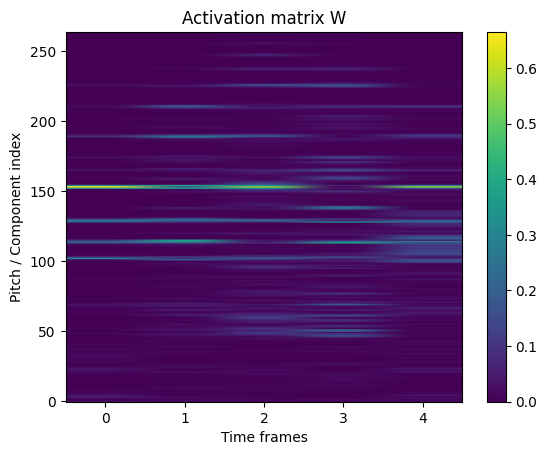

In [ ]:
'''W, H = snmf(
    V,
    rank=10,
    l1_target=5.0,
    l2_target=2.0,
    num_iters=200,
    mu=1e-3,
    seed=42
)'''
#V = np.abs(np.random.randn(50, 30))
W, H = snmf(
    spectrogram_norm[:,300:325],
    rank=5,
    l1_target=10.0,   # less restrictive
    l2_target=5.0,
    num_iters=100,
    mu=1e-2
)

print("Reconstruction error:", np.linalg.norm(spectrogram_norm[:,300:325] - W @ H))

import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(H_v, aspect='auto', origin='lower')
#plt.imshow(Y[:,140:160], aspect='auto', origin='lower')
plt.imshow(W, aspect='auto', origin='lower')
#plt.imshow(Y, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix W")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()


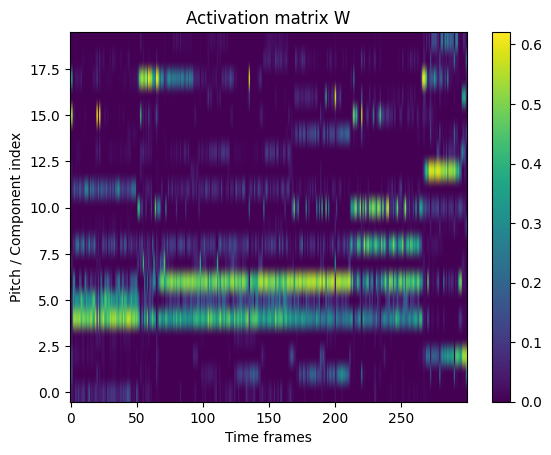

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(H_v, aspect='auto', origin='lower')
#plt.imshow(Y[:,140:160], aspect='auto', origin='lower')
plt.imshow(H, aspect='auto', origin='lower')
#plt.imshow(Y, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix W")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()


In [ ]:
error = np.linalg.norm(spectrogram_norm - W @ H)
normV = np.linalg.norm(spectrogram_norm)
print("Relative error:", error / normV)

Relative error: 0.4475924936966936


**Читаем исходный файл**

In [ ]:
from scipy.io import wavfile
import numpy as np
import librosa
import nimfa
np.Inf = np.inf
gamma = 100
fft_bins = 2048
onsets_mode = True
if(onsets_mode):
  pitch_count = 88 * 2
else:
  pitch_count = 88
f_s, x = wavfile.read("/content/Prelude-in-E-Minor-Nr-4.wav")
print(f_s)        # sample rate
print(x.dtype)   # int16, int32, etc.
print(x.shape)   # (N,) mono or (N, channels)
#print(x[100000])
def init_nmf_template_pitch(K, pitch_set, freq_res, tol_pitch=0.05):
    """Initializes template matrix for a given set of pitches

    Notebook: C8/C8S3_NMFSpecFac.ipynb

    Args:
        K (int): Number of frequency points
        pitch_set (np.ndarray): Set of fundamental pitches
        freq_res (float): Frequency resolution
        tol_pitch (float): Relative frequency tolerance for the harmonics (Default value = 0.05)

    Returns:
        W (np.ndarray): Nonnegative matrix of size K x R with R = len(pitch_set)
    """
    R = len(pitch_set)
    W = np.zeros((K, R))
    for r in range(R):
        W[:, r] = template_pitch(K, pitch_set[r], freq_res, tol_pitch=tol_pitch)
    return W
def init_nmf_template_pitch_onset(K, pitch_set, freq_res, tol_pitch=0.05):
    """Initializes template matrix with onsets for a given set of pitches

    Notebook: C8/C8S3_NMFSpecFac.ipynb

    Args:
        K (int): Number of frequency points
        pitch_set (np.ndarray): Set of fundamental pitches
        freq_res (float): Frequency resolution
        tol_pitch (float): Relative frequency tolerance for the harmonics (Default value = 0.05)

    Returns:
        W (np.ndarray): Nonnegative matrix of size K x (2R) with R = len(pitch_set)
    """
    R = len(pitch_set)
    W = np.zeros((K, 2*R))
    for r in range(R):
        W[:, 2*r] = 0.1
        W[:, 2*r+1] = template_pitch(K, pitch_set[r], freq_res, tol_pitch=tol_pitch)
    return W
def sparse_H(H,onsets):
  H_r = H.copy()
  for i in range(H_r.shape[1]):
    if(i in onsets or (i-1) in onsets or (i-2) in onsets):
      H[1::2,i] = 0
    else:
      H[0::2,i] = 0
  return H_r
def template_pitch(K, pitch, freq_res, tol_pitch=0.05):
    """Defines spectral template for a given pitch

    Notebook: C8/C8S3_NMFSpecFac.ipynb

    Args:
        K (int): Number of frequency points
        pitch (float): Fundamental pitch
        freq_res (float): Frequency resolution
        tol_pitch (float): Relative frequency tolerance for the harmonics (Default value = 0.05)

    Returns:
        template (np.ndarray): Nonnegative template vector of size K
    """
    max_freq = K * freq_res
    pitch_freq = 2**((pitch - 69) / 12) * 440
    max_order = int(np.ceil(max_freq / ((1 - tol_pitch) * pitch_freq)))
    #print(max_freq,pitch_freq,max_order)
    template = np.zeros(K)
    for m in range(1, max_order + 1):
        min_idx = max(0, int((1 - tol_pitch) * m * pitch_freq / freq_res))
        max_idx = min(K-1, int((1 + tol_pitch) * m * pitch_freq / freq_res))
        template[min_idx:max_idx+1] = 1 / m
    return template

if(x.dtype==np.int32):
  x = x / (2**31)
elif(x.dtype==np.int16):
  x = x / (2**15)
else:
  raise ValueError(f"Unsupported sample type: {x.dtype}")
onsets = librosa.onset.onset_detect(y=x, sr=f_s, hop_length=fft_bins//2,units='frames')

print(onsets)
spectrogram = np.abs(librosa.stft(x, n_fft=fft_bins,hop_length=fft_bins//2))
spectrogram_compressed = np.log(1+gamma*spectrogram)
pitches = [x+21 for x in range(88)]
freq_res = f_s/(2 * (fft_bins//2+1))

if(onsets_mode):
  W_temp = init_nmf_template_pitch_onset(fft_bins//2+1,pitches,freq_res)
else:
  W_temp = init_nmf_template_pitch(fft_bins//2+1,pitches,freq_res)
#W_temp = np.random.rand(spectrogram_compressed.shape[0],88)
H_temp = np.random.rand(pitch_count, spectrogram_compressed.shape[1])
if(onsets_mode):
  H_temp = sparse_H(H_temp,onsets)
#nmf = nimfa.Nmf(spectrogram_compressed, seed='fixed', W=W_temp)
print(W_temp.shape)
print(H_temp.shape)
nmf = nimfa.Nmf(
    spectrogram_compressed,
    rank=pitch_count,
    seed='fixed',
    W=W_temp,
    H=H_temp,
    max_iter=200,
    objective='div',
    update='divergence',
    beta=1, sparsity=(None, 0.2)
)
nmf_fit = nmf()
W_est = nmf_fit.basis()
H_est = nmf_fit.coef()

if(onsets_mode):
  H_new = H_est[1::2]
else:
  H_new = H_est.copy()

44100
int32
(5695232,)
[  87  140  152  181  233  255  278  300  325  353  384  407  430  453
  479  500  526  553  583  606  629  656  684  706  765  794  817  840
  895  920  983 1013 1037 1061 1087 1112 1135 1161 1191 1221 1244 1268
 1292 1318 1339 1364 1394 1420 1445 1467 1489 1512 1533 1567 1579 1591
 1616 1638 1688 1743 1767 1815 1838 1860 1884 1911 1934 1956 1986 2014
 2036 2058 2083 2134 2157 2188 2239 2283 2340 2358 2370 2411 2451 2478
 2501 2523 2544 2573 2596 2611 2631 2664 2687 2710 2733 2758 2784 2812
 2841 2869 2889 2911 2933 2956 2958 2979 2982 3001 3024 3026 3050 3072
 3095 3117 3162 3181 3201 3203 3229 3239 3250 3269 3272 3277 3283 3288
 3296 3314 3333 3355 3370 3382 3404 3428 3452 3472 3494 3516 3537 3560
 3580 3602 3623 3631 3641 3663 3689 3714 3744 3769 3800 3823 3845 3867
 3942 3953 3980 4007 4030 4077 4103 4130 4160 4181 4199 4231 4254 4279
 4305 4334 4360 4385 4418 4448 4472 4498 4525 4584 4620 4690 4909 5036
 5228]
(1025, 176)
(176, 5562)


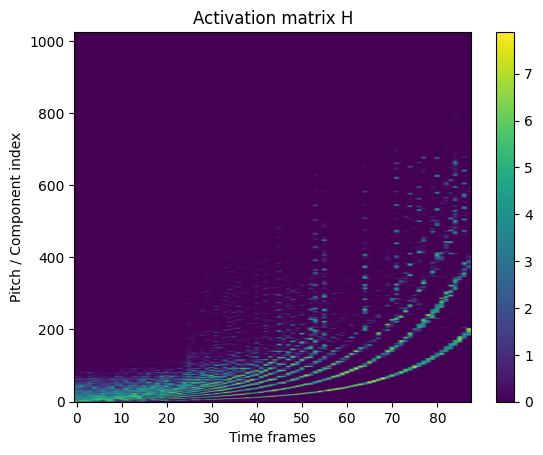

[[1.03138082e-08]
 [6.15499317e+00]
 [5.91197950e+00]
 ...
 [1.08448427e-04]
 [4.15582273e-05]
 [9.56838655e-06]]


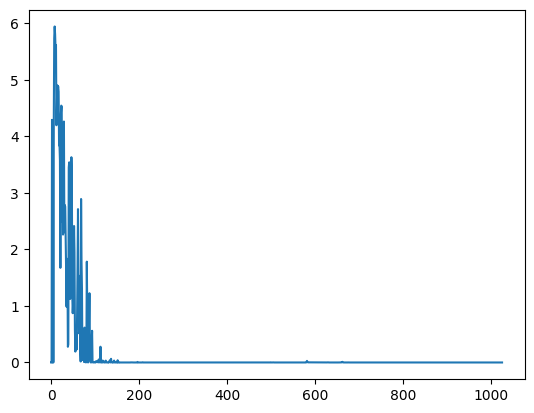

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(H_v, aspect='auto', origin='lower')
W_n = W_est[:,1::2]
W_n_vis = np.log(1+100*W_n)
plt.imshow(W_n_vis, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix H")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()
print(W_n_vis[:,0])


import matplotlib.pyplot as plt

plt.plot(W_n_vis[:,10])
plt.show()

In [ ]:
print(len(res))
print(type(x))
print(x.shape)
print(x.dtype)
print(np.min(x), np.max(x))
print(np.isnan(x).any(), np.isinf(x).any())

254
<class 'numpy.ndarray'>
(5695232,)
float64
-0.7204957604408264 0.8912509083747864
False False


In [ ]:
from scipy.io import wavfile
import numpy as np
import librosa
import nimfa
np.Inf = np.inf
gamma = 100
fft_bins = 2048
onsets_mode = True
if(onsets_mode):
  pitch_count = 88 * 2
else:
  pitch_count = 88
f_s, x = wavfile.read("/content/Prelude-in-E-Minor-Nr-4.wav")
print(f_s)        # sample rate
print(x.dtype)   # int16, int32, etc.
print(x.shape)   # (N,) mono or (N, channels)
#print(x[100000])
def init_nmf_template_pitch(K, pitch_set, freq_res, tol_pitch=0.05):
    """Initializes template matrix for a given set of pitches

    Notebook: C8/C8S3_NMFSpecFac.ipynb

    Args:
        K (int): Number of frequency points
        pitch_set (np.ndarray): Set of fundamental pitches
        freq_res (float): Frequency resolution
        tol_pitch (float): Relative frequency tolerance for the harmonics (Default value = 0.05)

    Returns:
        W (np.ndarray): Nonnegative matrix of size K x R with R = len(pitch_set)
    """
    R = len(pitch_set)
    W = np.zeros((K, R))
    for r in range(R):
        W[:, r] = template_pitch(K, pitch_set[r], freq_res, tol_pitch=tol_pitch)
    return W
def init_nmf_template_pitch_onset(K, pitch_set, freq_res, tol_pitch=0.05):
    """Initializes template matrix with onsets for a given set of pitches

    Notebook: C8/C8S3_NMFSpecFac.ipynb

    Args:
        K (int): Number of frequency points
        pitch_set (np.ndarray): Set of fundamental pitches
        freq_res (float): Frequency resolution
        tol_pitch (float): Relative frequency tolerance for the harmonics (Default value = 0.05)

    Returns:
        W (np.ndarray): Nonnegative matrix of size K x (2R) with R = len(pitch_set)
    """
    R = len(pitch_set)
    W = np.zeros((K, 2*R))
    for r in range(R):
        W[:, 2*r] = 0.1
        W[:, 2*r+1] = template_pitch(K, pitch_set[r], freq_res, tol_pitch=tol_pitch)
    return W
def sparse_H(H,onsets):
  H_r = H.copy()
  for i in range(H_r.shape[1]):
    if(i in onsets or (i-1) in onsets or (i-2) in onsets):
      H[1::2,i] = 0
    else:
      H[0::2,i] = 0
  return H_r
def template_pitch(K, pitch, freq_res, tol_pitch=0.05):
    """Defines spectral template for a given pitch

    Notebook: C8/C8S3_NMFSpecFac.ipynb

    Args:
        K (int): Number of frequency points
        pitch (float): Fundamental pitch
        freq_res (float): Frequency resolution
        tol_pitch (float): Relative frequency tolerance for the harmonics (Default value = 0.05)

    Returns:
        template (np.ndarray): Nonnegative template vector of size K
    """
    max_freq = K * freq_res
    pitch_freq = 2**((pitch - 69) / 12) * 440
    max_order = int(np.ceil(max_freq / ((1 - tol_pitch) * pitch_freq)))
    #print(max_freq,pitch_freq,max_order)
    template = np.zeros(K)
    for m in range(1, max_order + 1):
        min_idx = max(0, int((1 - tol_pitch) * m * pitch_freq / freq_res))
        max_idx = min(K-1, int((1 + tol_pitch) * m * pitch_freq / freq_res))
        template[min_idx:max_idx+1] = 1 / m
    return template

if(x.dtype==np.int32):
  x = x / (2**31)
elif(x.dtype==np.int16):
  x = x / (2**15)
else:
  raise ValueError(f"Unsupported sample type: {x.dtype}")
onsets = librosa.onset.onset_detect(y=x, sr=f_s, hop_length=fft_bins//2,units='frames')

print(onsets)
spectrogram = np.abs(librosa.stft(x, n_fft=fft_bins,hop_length=fft_bins//2))
spectrogram_compressed = np.log(1+gamma*spectrogram)
pitches = [x+21 for x in range(88)]
freq_res = f_s/(2 * (fft_bins//2+1))

if(onsets_mode):
  W_temp = init_nmf_template_pitch_onset(fft_bins//2+1,pitches,freq_res)
else:
  W_temp = init_nmf_template_pitch(fft_bins//2+1,pitches,freq_res)
#W_temp = np.random.rand(spectrogram_compressed.shape[0],88)
H_temp = np.random.rand(pitch_count, spectrogram_compressed.shape[1])
if(onsets_mode):
  H_temp = sparse_H(H_temp,onsets)
#nmf = nimfa.Nmf(spectrogram_compressed, seed='fixed', W=W_temp)
print(W_temp.shape)
print(H_temp.shape)
'''nmf = nimfa.Nmf(
    spectrogram_compressed,
    rank=pitch_count,
    seed='fixed',
    W=W_temp,
    H=H_temp,
    max_iter=200,
    beta=1, sparsity=(None, 0.2),
    update='divergence',
    objective='div'
)'''

nmf = nimfa.Snmf(
    spectrogram_compressed,
    rank=pitch_count,
    seed='fixed',
    W=W_temp,
    H=H_temp,
    max_iter=200,
    beta=1, sparsity=(None, 0.2),
    update='divergence',
    objective='div'
)
nmf_fit = nmf()
W_est = nmf_fit.basis()
H_est = nmf_fit.coef()

if(onsets_mode):
  H_new = H_est[1::2]
else:
  H_new = H_est.copy()

44100
int32
(5695232,)
[  87  140  152  181  233  255  278  300  325  353  384  407  430  453
  479  500  526  553  583  606  629  656  684  706  765  794  817  840
  895  920  983 1013 1037 1061 1087 1112 1135 1161 1191 1221 1244 1268
 1292 1318 1339 1364 1394 1420 1445 1467 1489 1512 1533 1567 1579 1591
 1616 1638 1688 1743 1767 1815 1838 1860 1884 1911 1934 1956 1986 2014
 2036 2058 2083 2134 2157 2188 2239 2283 2340 2358 2370 2411 2451 2478
 2501 2523 2544 2573 2596 2611 2631 2664 2687 2710 2733 2758 2784 2812
 2841 2869 2889 2911 2933 2956 2958 2979 2982 3001 3024 3026 3050 3072
 3095 3117 3162 3181 3201 3203 3229 3239 3250 3269 3272 3277 3283 3288
 3296 3314 3333 3355 3370 3382 3404 3428 3452 3472 3494 3516 3537 3560
 3580 3602 3623 3631 3641 3663 3689 3714 3744 3769 3800 3823 3845 3867
 3942 3953 3980 4007 4030 4077 4103 4130 4160 4181 4199 4231 4254 4279
 4305 4334 4360 4385 4418 4448 4472 4498 4525 4584 4620 4690 4909 5036
 5228]
(1025, 176)
(176, 5562)


/usr/local/lib/python3.12/dist-packages/nimfa/methods/factorization/snmf.py:563: RuntimeWarning: invalid value encountered in divide
  t_d = D[l_1n, l_2n] / (D[l_1n, l_2n] - K[l_1n, l_2n])
/usr/local/lib/python3.12/dist-packages/nimfa/methods/factorization/snmf.py:563: RuntimeWarning: invalid value encountered in divide
  t_d = D[l_1n, l_2n] / (D[l_1n, l_2n] - K[l_1n, l_2n])
/usr/local/lib/python3.12/dist-packages/nimfa/methods/factorization/snmf.py:569: RuntimeWarning: invalid value encountered in subtract
  D[:, h_set] = D[:, h_set] - multiply(
/usr/local/lib/python3.12/dist-packages/nimfa/methods/factorization/snmf.py:563: RuntimeWarning: invalid value encountered in divide
  t_d = D[l_1n, l_2n] / (D[l_1n, l_2n] - K[l_1n, l_2n])
/usr/local/lib/python3.12/dist-packages/nimfa/methods/factorization/snmf.py:569: RuntimeWarning: invalid value encountered in subtract
  D[:, h_set] = D[:, h_set] - multiply(
/usr/local/lib/python3.12/dist-packages/nimfa/methods/factorization/snmf.py:569: Ru

ValueError: operands could not be broadcast together with shapes (176,5117) (176,5119) 

/tmp/ipykernel_4153/3091653800.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tempo = float(tempo)          # or: tempo = tempo.item()


Estimated tempo: 114.84 BPM
beat_frames= [152, 173, 194, 215, 236, 257, 278, 299, 322, 344, 367, 389, 412, 434, 456, 478, 500, 527, 553, 575, 597, 619, 641, 663, 684, 705, 725, 745, 765, 787, 810, 832, 854, 876, 898, 920, 940, 962, 983, 1005, 1027, 1049, 1070, 1092, 1113, 1135, 1154, 1173, 1191, 1213, 1234, 1255, 1276, 1297, 1318, 1339, 1360, 1382, 1403, 1425, 1446, 1468, 1489, 1511, 1533, 1556, 1578, 1602, 1625, 1649, 1672, 1695, 1719, 1742, 1766, 1790, 1814, 1838, 1859, 1884, 1911, 1933, 1956, 1979, 2001, 2023, 2046, 2068, 2090, 2112, 2134, 2157, 2180, 2203, 2226, 2249, 2272, 2295, 2318, 2341, 2364, 2387, 2410, 2433, 2455, 2478, 2501, 2523, 2548, 2573, 2596, 2611, 2631, 2653, 2675, 2697, 2719, 2740, 2762, 2783, 2806, 2828, 2850, 2872, 2894, 2916, 2938, 2960, 2982, 3004, 3026, 3050, 3072, 3094, 3116, 3139, 3161, 3182, 3203, 3221, 3239, 3260, 3282, 3308, 3333, 3357, 3381, 3403, 3428, 3452, 3471, 3493, 3516, 3537, 3559, 3580, 3602, 3623]
Beat positions (sec.): [ 3.54104308  4.02866213  

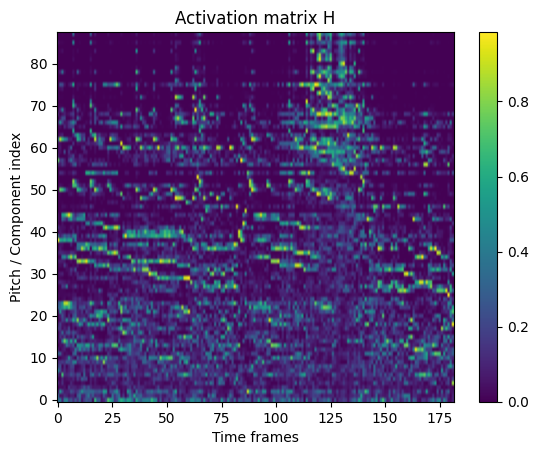

[12, 18, 22, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 53, 54, 55, 56, 57, 58, 60, 61, 62, 65, 66, 68, 69, 70, 75, 80, 81]
45
[12, 18, 22, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 53, 54, 55, 56, 57, 58, 60, 61, 62, 65, 66, 68, 69, 70, 75, 80, 81]
45


In [ ]:
from scipy.ndimage import label
from scipy.ndimage import gaussian_filter1d
tempo, beats = librosa.beat.beat_track(y=x, sr=f_s)

tempo = float(tempo)          # or: tempo = tempo.item()

print(f"Estimated tempo: {tempo:.2f} BPM")

beat_times = librosa.frames_to_time(beats, sr=f_s)
beat_frames = list(map(int, beat_times * f_s / 1024))
print("beat_frames=",beat_frames)
print(f"Beat positions (sec.): {beat_times}")

def norm_dynamic_range(H):
  H_min = np.min(H)
  H_max = np.max(H)
  H_mean = np.mean(H)
  Z = (H-H_mean)/(H_max-H_min)
  Y = 1 / (1+np.exp(-Z))
  return Y
def transcribe_frame(fr,thr=0.1,pol=9):
  peaks = top_k_indices(fr,20)
  notes = []
  for p in peaks:
    a = [p+12,p+19,p+24,p+28,p+31,p+34,p+36]
    notes.add((p,len(a & peaks)))

  sorted(list_of_tuples, key=lambda x: x[1])
def matrix_filter(H):
  H_c = H.copy()
  for i in range(H_c.shape[0]):
    for j in range(H_c.shape[1]):
      v = 0
      if ((j-1)>=0):
        v += H_c[i,j-1]
      if((j+1)<H_c.shape[1]):
        v += H_c[i,j+1]
      v += H_c[i,j]
      v = v / 3
      H_c[i,j] = v
  return H_c

def enforce_min_duration(B, min_len=10):
    for q in range(B.shape[0]):
        labels, n = label(B[q])
        for i in range(1, n+1):
            if np.sum(labels == i) < min_len:
                B[q][labels == i] = 0
    return B

def rowwise_norm(H, eps=1e-8):
    Hn = H.copy()
    for q in range(H.shape[0]):
        m = np.max(Hn[q])
        if m > eps:
            Hn[q] /= m
    return Hn
def find_local_max(Y):
  mx = []
  for i in range(1,Y.shape[0]):
    v = np.max(Y[i,:])
    if(v > 0.922):
      mx.append(i)
  return mx
def maximize_h(H,onsets):
  maxlist = []
  for i in range(len(onsets)-1):
    cur_max = onsets[i]
    for j in range(onsets[i],onsets[i+1]):
      if(np.std(np.array(H[:,cur_max])) < np.std(np.array(H[:,j]))):
        cur_max = j
    maxlist.append(cur_max)
  return H[:,maxlist]

def unsharp_mask_mean(x, window=5, amount=1.0):
    """
    Simple mean-value unsharp masking of a 1D vector.

    Parameters
    ----------
    x : array-like
        Input vector.
    window : int
        Size of moving average window.
    amount : float
        Sharpening strength.

    Returns
    -------
    y : numpy array
        Sharpened vector.
    """

    x = np.asarray(x, dtype=float).ravel()

    kernel = np.ones(window) / window
    blurred = np.convolve(x, kernel, mode='same')

    detail = x - blurred
    y = x + amount * detail

    return y
def unsharp_matrix(Y):
  Y_c = np.zeros(Y.shape)
  for i in range(Y.shape[1]):
    #print(np.array(Y[:,i]))
    Y_c[:,i] = unsharp_mask_mean(np.array(Y[:,i]))
  return Y_c
#Y = norm_dynamic_range(H_new)
Y = rowwise_norm(H_new)
Y = matrix_filter(Y)
#Y = unsharp_matrix(Y)
#Y = np.maximum(0, Y)
#Y = freq_ftr(Y)
#Y = binarize_matrix(Y)
#Y = track_notes(Y)
Y = enforce_min_duration(Y)
#Y[0,:] = 0
#H_v = np.asarray(H_v)
#H_v = beat_sync_H(H_v,beat_frames)
#print(res)

#H_v = generate_transcription(H_v,res)
#H_v = enforce_min_duration(H_v)

H_m = maximize_h(Y,onsets)

import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(H_v, aspect='auto', origin='lower')
#plt.imshow(Y[:,140:160], aspect='auto', origin='lower')
plt.imshow(H_m, aspect='auto', origin='lower')
#plt.imshow(Y, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix H")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()


print(find_local_max(Y))
print(len(find_local_max(Y)))
sp_max = find_local_max(Y)
print(sp_max)
print(len(sp_max))
#print(maximize_h(Y,onsets))
#print(maximize_h(H_m,onsets))

/tmp/ipykernel_4153/2733800965.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if(float(sc*fr[peaks[p]])<=thr):
/tmp/ipykernel_4153/2733800965.py:77: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  notes.append((peaks[p],float(sc*fr[peaks[p]])))


[13]


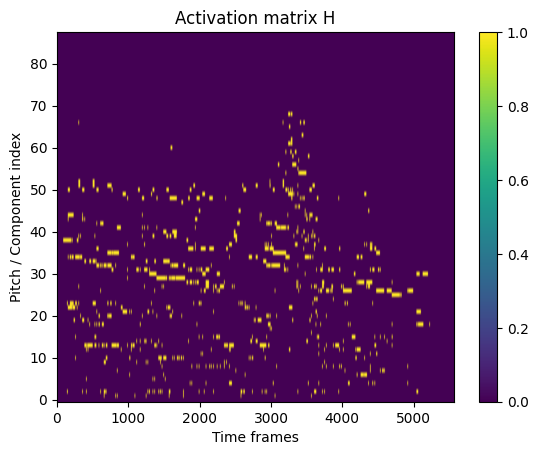

In [ ]:

def pitch_energy(fp,p):
  en = 0
  en_t = np.sum(np.square(fp))
  h = pitch_harmonics(p)
  h = [m for m in h if m <= 87]
  alpha = -1
  #print(h)
  for l in range(len(h)):
    en += (l+2)**alpha * fp[h[l]]**2
    #print(l,h[l])
  #print(en)
  return float(en)
'''def transcribe_frame(fr,pol=9):
  peaks = [int(p) for p in top_k_indices(fr,20)]
  notes = []
  thr = np.median(fr,axis=0)
  thr += 0.1
  alpha = -1
  print(fr.shape)
  for p in peaks:
    #a = [p+12,p+19,p+24,p+28,p+31,p+34,p+36]
    if(fr[p]>thr):
      a = pitch_harmonics(p)
      sc = 0
      for pt in range(len(a)):
        if a[pt] in peaks:
          sc += (pt+2)**alpha
      #notes.append((p,float(fr[p,0]),len(set(a) & set(peaks))))
      #notes.append((p,float(fr[p,0]),sc))
      notes.append((p,pitch_energy(fr,p)))
  notes = sorted(notes, key=lambda x: x[1],reverse=True)
  return notes
  print(notes)'''
'''def top_k_indices(v, k):
    v = np.asarray(v).ravel()      # ensure 1D ndarray
    return np.argpartition(v, -k)[-k:]'''

def top_k_indices(v, k):
    v = np.asarray(v).ravel()          # ensure 1D
    idx = np.argpartition(v, -k)[-k:]  # indices of k largest elements
    idx = idx[np.argsort(v[idx])[::-1]]  # sort them by value (descending)
    return idx
def pitch_harmonics(p):
  r = [p+12,p+19,p+24,p+28,p+31,p+34,p+36]
  return [m for m in r if m <= 87]
def transcribe_frame(fr,thr=0.18):
  frn = fr.copy()
  peaks = [int(p) for p in top_k_indices(fr,20)]
  #peaks = [int(p) for p in range(88) if fr[p] > 0.25]
  peaks = sorted(peaks)
  #print(peaks)
  alpha = 0.5
  rv_start = 0.7
  notes = []
  for p in range(len(peaks)):
    frns = frn.copy()
    sc = 0
    en = fr[peaks[p]]
    pch = pitch_harmonics(peaks[p])
    ind = []
    for idx in range(len(pch)):
      if(frn[pch[idx]]>rv_start*(alpha)**idx):
        sc += 1/(idx+1)
        '''* float(frn[pch[idx]])**2'''
        frn[pch[idx]] -= rv_start*(alpha)**idx
        ind.append(idx)
    #score correction
    '''if(peaks[p]<=87):
      sc *= 2**((peaks[p] - 69) / 12)'''
    #sc *= float(frn[peaks[p]]/(np.max(frn)))
    #notes.append((peaks[p],sc))
    '''if(float(sc*fr[peaks[p]])<=thr):
      for i in ind:
        frn[pch[i]] += rv_start*(alpha)**i'''
    if(float(sc*fr[peaks[p]])<=thr):
      frn = frns
    notes.append((peaks[p],float(sc*fr[peaks[p]])))
  notes = sorted(notes, key=lambda x: x[1],reverse=True)
  notes = list(filter(lambda t: t[1] > thr, notes))
  return [t[0] for t in notes]
  #print(notes)

def transcribe_onset(m):
  st = np.zeros((88,))
  #ln = m.shape[1] // 2
  r = []
  #print("ln",ln)
  for j in range(m.shape[1]):
    for l in transcribe_frame(m[:,j]):
      st[l] +=1
  ap = [int(p) for p in top_k_indices(st,88)]
  s = 0
  summa = np.sum(st)
  for el in ap:
    s += st[el]
    if(s>=round((0.7 * summa)) or st[el]==0):
      break
    r.append(el)
    #print(el,st[el])
    #if(st[el]>ln):
    #  r.append(el)
  #print(np.sum(st))

  #print(st[ap[0]],st[ap[1]])
  #return ap
  #print(st[ap[0]],st[ap[1]])
  #print(st)
  return r
def transcribe_H(Y,os):
  tr = np.zeros(Y.shape)
  for idx in range(len(os)-1):
    nts = transcribe_onset(Y[:,os[idx]:os[idx]+10])
    for n in nts:
      tr[n,os[idx]:os[idx]+10] = 1
    for i in range(os[idx]+10,os[idx+1]):
      for n in nts:
        if(np.max(Y[n,i-4:i+4])>0.5):
          tr[n,i] = 1
        #else:
        #  nts.remove(n)
      #if(len(nts)==0):
        #break
  '''nts = transcribe_onset(Y[:,os[len(os)-1]:os[len(os)-1]+10])
  for n in nts:
    tr[n,os[len(os)-1]:os[len(os)-1]+10] = 1
  print(Y.shape[1])
  for i in range(os[len(os)-1]+10,Y.shape[1]-5):
    for n in nts:
      if(np.max(Y[n,i-4:i+5])>0.5):
        tr[n,i] = 1'''
  return tr

def pitch_energy(fp,p):
  en = 0
  en_t = np.sum(np.square(fp))
  h = pitch_harmonics(p)
  h = [m for m in h if m <= 87]
  #print(h)
  for l in h:
    en += fp[l]**2
  #print(en)
  return float(en/en_t)
  #return en[0,0]
#print(transcribe_frame(H_m[:,1]))
print(transcribe_onset(Y[:,479:489]))
#print(transcribe_frame(Y[:,152]))
#print(Y[38,203],Y[39,203])

trscrptn = transcribe_H(Y,onsets)
trscrptn[0,:] = 0
trscrptn = enforce_min_duration(trscrptn,min_len=10)
import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(H_v, aspect='auto', origin='lower')
#plt.imshow(Y[:,140:160], aspect='auto', origin='lower')
#plt.imshow(Y[:,479:489], aspect='auto', origin='lower')
plt.imshow(trscrptn, aspect='auto', origin='lower')
#plt.imshow(Y, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix H")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()


0.0 1.0
[0. 1.]
(88, 5562)


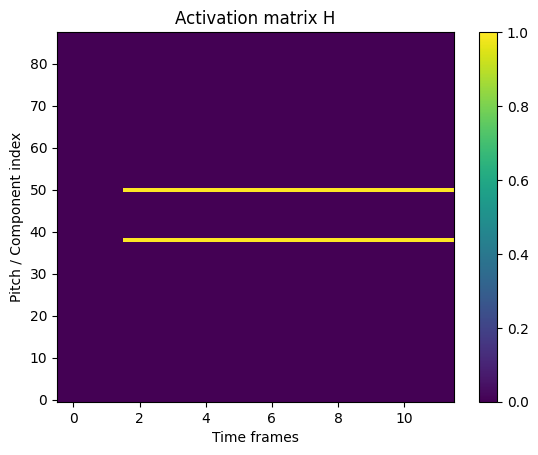

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
m = trscrptn[:,138:150]
print(np.min(m), np.max(m))
print(np.unique(m))
print(trscrptn.shape)
import matplotlib.pyplot as plt
plt.imshow(m, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix H")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()
print(m[:,2])

In [ ]:
def pitch_energy(fp,p):
  en = 0
  en_t = np.sum(np.square(fp))
  h = pitch_harmonics(p)
  h = [m for m in h if m <= 87]
  alpha = -1
  #print(h)
  for l in range(len(h)):
    en += (l+2)**alpha * fp[h[l]]**2
    #print(l,h[l])
  #print(en)
  return float(en)
  #return float(en/en_t)
'''def pitch_energy(fp,p):
  en = 0
  en_t = np.sum(np.square(fp))
  h = [pitch_harmonics(p) for p in pc]
  h = [m for m in h if m <= 87]
  #print(h)
  for l in h:
    en += fp[l]**2
  #print(en)
  return float(en/en_t)'''
  #return en[0,0]
def transcribe_frame(fr,pol=9):
  #peaks = [int(p) for p in top_k_indices(fr,10)]
  #peaks = [int(p) for p in range(88) if fr[p]>(1/3) * np.max(fr)]
  peaks = [p for p in range(1,87) if fr[p]>0.1 * np.max(fr)]
  #peaks = [int(p) for p in top_k_indices(fr,20)]
  notes = []
  alpha = -1
  #thr = 0.33 * np.max(fr,axis=0)
  for p in peaks:
    a = pitch_harmonics(p)
    sc = 0
    for pt in range(len(a)):
      if a[pt] in peaks:
        sc += (pt+2)**alpha
    if(sc > 0 and fr[p]>0.2):
      #notes.append((p,float(fr[p,0]),sc))
      #notes.append((p,pitch_energy(fr[:,0],p),sc))
      notes.append((p,sc,float(fr[p])))
  notes = sorted(notes, key=lambda x: x[1],reverse=True)
  return notes
  print(notes)
print(transcribe_frame(H_m[:,4]))
#print(transcribe_frame(Y[:,155]))
#print(transcribe_frame(Y[:,384]))
#print(pitch_energy(Y[:,152],50))
print(np.sum(np.square(Y[:, 152])))
#print(Y[:,152].shape)
print(Y[38,203],Y[39,203])

[(34, 1.0928571428571427, 0.42412418461924273), (19, 1.0749999999999997, 0.24138565184479843), (43, 0.9999999999999999, 0.3262244993163325), (16, 0.7595238095238095, 0.5357333814156702), (44, 0.75, 0.44530836479146885), (50, 0.75, 0.4371218865088804), (23, 0.5595238095238095, 0.5426959285110801), (13, 0.5095238095238095, 0.5395919561636539), (1, 0.5, 0.21608037145305461), (56, 0.5, 0.45737340971733037), (6, 0.34285714285714286, 0.3221584588275393), (39, 0.3333333333333333, 0.7574165389731057), (47, 0.3333333333333333, 0.2940207553036874), (55, 0.3333333333333333, 0.4685803552485164), (9, 0.30952380952380953, 0.4117345110989932)]
4.65828664979481
0.17900654930409488 0.5979365170742806


/tmp/ipykernel_581/2947067164.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  notes.append((p,sc,float(fr[p])))


In [ ]:
pc = [6,8,10,21]
h = [pitch_harmonics(p) for p in pc]
fh = list(set([item for sublist in h for item in sublist]))
print(sorted(fh))

[18, 20, 22, 25, 27, 29, 30, 32, 33, 34, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 49, 52, 55, 57]


In [ ]:
print(H_v)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


# Оценка результатов транскрибирования

In [31]:
pip install pretty_midi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 68.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.4 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=0cf7650f73664a5daca89ef2f9ad7ac21339d915a571042536bc5dcc947b9acf
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [33]:
import pretty_midi
midi = pretty_midi.PrettyMIDI("Prelude-in-E-Minor-Nr-4.mid")

pitches = set()

for instrument in midi.instruments:
    for note in instrument.notes:
        pitches.add(note.pitch)

#print(len(sorted(pitches)))
#print(len(sorted(sp_max)))
#print(len(set(sp_max) & set(pitches)))

In [34]:
import numpy as np
import pretty_midi

def midi_to_binary_matrix(
    midi_input,
    dt=0.02,                     # time quantum in seconds
    pitch_range=(21, 108),  # A0–C8 by default
    min_overlap=0.5         # fraction of frame that must be covered
):
    """
    Convert MIDI to binary (88 x T) note activation matrix using fixed time grid.

    A note is active in a frame if it overlaps the frame
    by at least min_overlap * dt.
    """

    if dt <= 0:
        raise ValueError("dt must be positive (seconds)")

    # Load MIDI
    if isinstance(midi_input, pretty_midi.PrettyMIDI):
        pm = midi_input
    else:
        pm = pretty_midi.PrettyMIDI(midi_input)

    # Time axis
    total_time = pm.get_end_time()
    T = int(np.ceil(total_time / dt))
    frame_times = np.arange(T) * dt

    n_pitches = pitch_range[1] - pitch_range[0] + 1
    B = np.zeros((n_pitches, T), dtype=np.uint8)

    # Process notes
    for instrument in pm.instruments:
        if instrument.is_drum:
            continue

        for note in instrument.notes:
            if not (pitch_range[0] <= note.pitch <= pitch_range[1]):
                continue

            p = note.pitch - pitch_range[0]

            start_frame = int(np.floor(note.start / dt))
            end_frame   = int(np.ceil(note.end   / dt))

            for t in range(start_frame, min(end_frame, T)):
                frame_start = t * dt
                frame_end   = frame_start + dt

                overlap = max(
                    0.0,
                    min(note.end, frame_end) - max(note.start, frame_start)
                )

                if overlap >= min_overlap * dt:
                    B[p, t] = 1

    return B, frame_times

(88, 5513) (88, 5562)


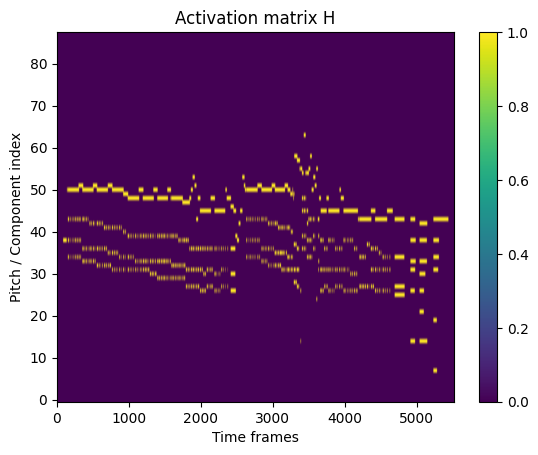

In [35]:
# 20 ms frames (matches typical STFT hop ~512 @ 44.1kHz)
dt = 1024 / f_s
#print(dt)
#dt = 0.023
B, times = midi_to_binary_matrix(
    "Prelude-in-E-Minor-Nr-4.mid",
    dt=dt
)
print(B.shape,trscrptn.shape)
#print(H_v.shape, B.shape)   # (88, T)
import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(H_v, aspect='auto', origin='lower')
plt.imshow(B, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Activation matrix H")
plt.xlabel("Time frames")
plt.ylabel("Pitch / Component index")
plt.show()

In [36]:
def evaluate_results(H_et,H):
  #H_et - reference transcription of the piece
  #H - estimated transcription of the piece
  assert H_et.shape == H.shape
  P = 0
  R = 0
  F1 = 0
  TP = 0
  FP = 0
  FN = 0
  for i in range(H_et.shape[1]):
    TP += sum(1 for t, p in zip(H_et[:,i], H[:,i]) if t == 1 and p == 1)
    FP += sum(1 for t, p in zip(H_et[:,i], H[:,i]) if t == 0 and p == 1)
    FN += sum(1 for t, p in zip(H_et[:,i], H[:,i]) if t == 1 and p == 0)
  P = TP / (TP + FP)
  R = TP / (TP + FN)
  F1 = 2 * P * R / (P + R)
  return (P,R,F1)

In [ ]:
a = [0,1,1,1,0]
b = [1,1,1,0,0]
def top_k_indices(v, k):
    v = np.asarray(v).ravel()      # ensure 1D ndarray
    return np.argpartition(v, -k)[-k:]
print(top_k_indices(b,3))

[1 0 2]


In [43]:
print(evaluate_results(trscrptn[:,:B.shape[1]],B))
#print(evaluate_results(trscrptn,B[:,:trscrptn.shape[1]]))
#print(trscrptn[:,B.shape[1]].shape)
#print(B.shape)

(0.38678051865907653, 0.4716089848645522, 0.4250032578949655)
